### Zero inflated poisson distribution


#### Fixed omega

In [15]:
#library(VGAM)
library('distributions3')
library(actuar)

In [16]:
dzipois

function (x, lambda, pi, log = FALSE) 
{
    if (any(pi < 0) | any(pi > 1)) 
        warning("'pi' must be in [0, 1]")
    rval <- log(1 - pi) + dpois(x, lambda = lambda, log = TRUE)
    if (any(x0 <- (x == 0L))) 
        rval[x0] <- log(exp(rval) + pi)[x0]
    if (log) 
        rval
    else exp(rval)
}
<bytecode: 0x7fd0146c66d8>
<environment: namespace:distributions3>

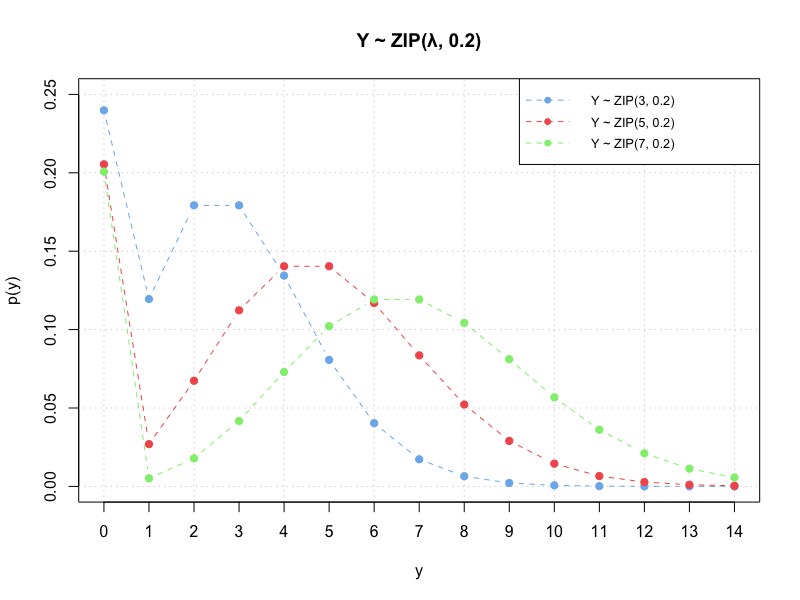

In [17]:
x_values <- 0:14
my_colors <- c("#7cb5ec", "#f45b5b", "#90ed7d")
par(bg = "white", mfrow = c(1, 1)) 
fixed_omega <- 0.2
lambdas <- c(3, 5, 7)
plot(0, 0, type = "n", 
     xlim = c(0, 14), 
     ylim = c(0, 0.25), 
     xlab = "y",
     ylab = "p(y)",
     main = "Y ~ ZIP(\u03bb, 0.2)",
     xaxt = "n")

grid(nx = NULL, ny = NULL, col = "lightgray", lty = "dotted")
axis(1, at = x_values)

for(i in 1:3) {
  y_vals <- dzipois(x_values, lambdas[i], fixed_omega)
  lines(x_values, y_vals, type = "b", pch = 19, lty = 2, col = my_colors[i])
}

legend("topright", 
       legend = paste0("Y ~ ZIP(", lambdas, ", ", fixed_omega, ")"),
       col = my_colors, 
       pch = 19, 
       lty = 2, 
       bg = "white", 
       cex = 0.8)


#### Fixed lambda

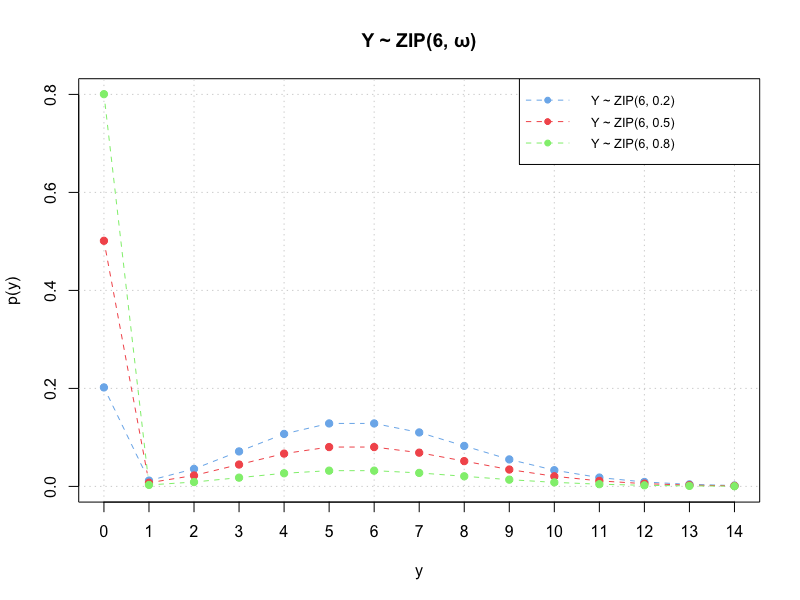

In [18]:
par(bg = "white", mfrow = c(1, 1)) 

my_colors <- c("#7cb5ec", "#f45b5b", "#90ed7d")

fixed_lambda <- 6
omegas <- c(0.2, 0.5, 0.8)
x_values <- 0:14

plot(0, 0, type = "n",
     xlim = c(0, 14),
     ylim = c(0, 0.8),
     xlab = "y",
     ylab = "p(y)",
     main = "Y ~ ZIP(6, \u03c9)",
     xaxt = "n")

grid(nx = NULL, ny = NULL, col = "lightgray", lty = "dotted")
axis(1, at = x_values)

for(i in 1:3) {
  y_vals <- dzipois(x_values,
                    fixed_lambda,
                    omegas[i])
  
  lines(x_values, y_vals,
        type = "b",
        pch = 19,
        lty = 2,
        col = my_colors[i])
}

legend("topright",
       legend = paste0("Y ~ ZIP(", fixed_lambda, ", ", omegas, ")"),
       col = my_colors,
       pch = 19,
       lty = 2,
       bg = "white",
       cex = 0.8)


### Zero inflated negative binominal

#### Fixed omega and p

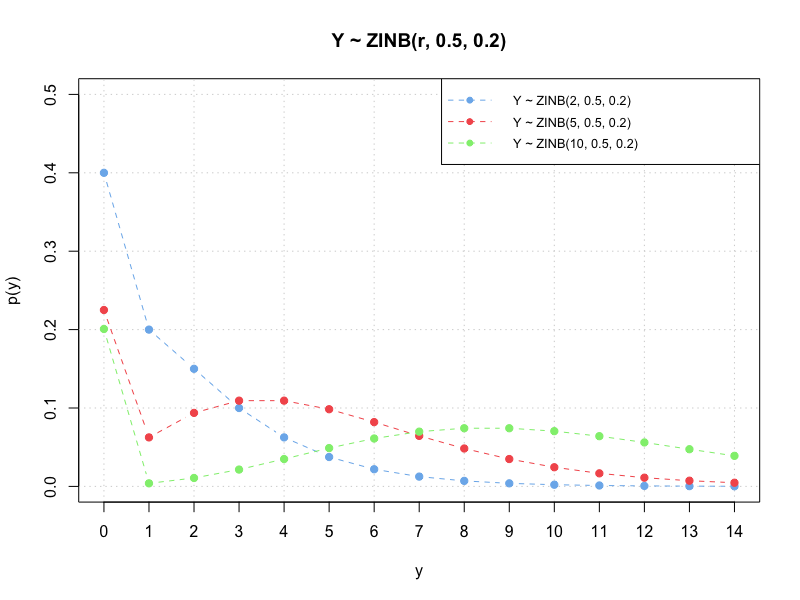

In [19]:
y_values <- 0:14
my_colors <- c("#7cb5ec", "#f45b5b", "#90ed7d")

par(bg = "white", mfrow = c(1, 1)) 

fixed_p     <- 0.5
fixed_omega <- 0.2
rs          <- c(2, 5, 10)

plot(0, 0, type = "n",
     xlim = c(0, 14),
     ylim = c(0, 0.50),
     xlab = "y",
     ylab = "p(y)",
     main = "Y ~ ZINB(r, 0.5, 0.2)",
     xaxt = "n")

grid(nx = NULL, ny = NULL, col = "lightgray", lty = "dotted")
axis(1, at = y_values)

for(i in 1:3) {
  probs <- dzinegbin(y_values,
                     size  = rs[i],      # r
                     prob  = fixed_p,    # p
                     pstr0 = fixed_omega # ω
                     )
  
  lines(y_values, probs,
        type = "b",
        pch = 19,
        lty = 2,
        col = my_colors[i])
}


legend("topright",
       legend = paste0("Y ~ ZINB(", rs, ", ", fixed_p, ", ", fixed_omega, ")"),
       col = my_colors,
       pch = 19,
       lty = 2,
       bg = "white",
       cex = 0.8)


#### Fixed omega and r


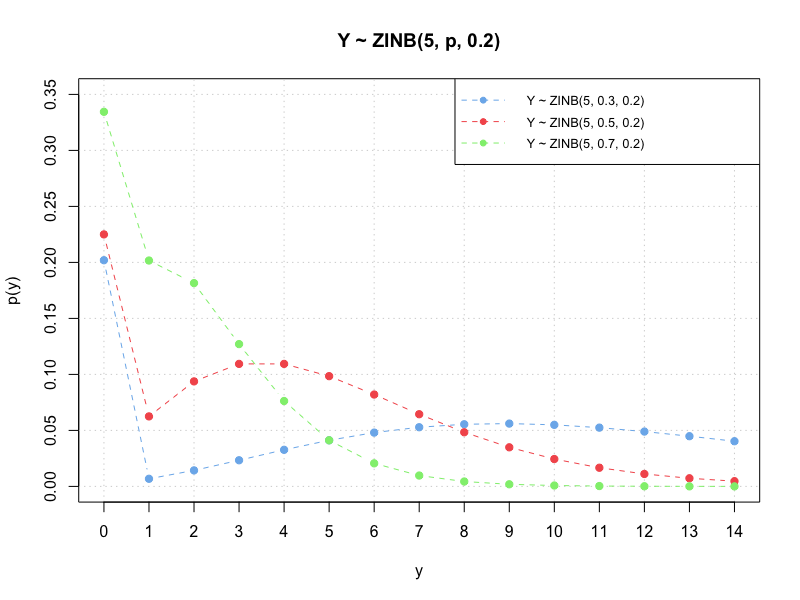

In [20]:

par(bg = "white", mfrow = c(1, 1)) 

fixed_r     <- 5
fixed_omega <- 0.2
ps          <- c(0.3, 0.5, 0.7)
y_values    <- 0:14
my_colors   <- c("#7cb5ec", "#f45b5b", "#90ed7d")

plot(0, 0, type = "n",
     xlim = c(0, 14),
     ylim = c(0, 0.35),
     xlab = "y",
     ylab = "p(y)",
     main = "Y ~ ZINB(5, p, 0.2)",
     xaxt = "n")

grid(nx = NULL, ny = NULL, col = "lightgray", lty = "dotted")
axis(1, at = y_values)

for(i in 1:3) {
  probs <- dzinegbin(y_values,
                     size  = fixed_r,     # r
                     prob  = ps[i],       # p
                     pstr0 = fixed_omega  # ω
                     )
  
  lines(y_values, probs,
        type = "b",
        pch = 19,
        lty = 2,
        col = my_colors[i])
}

legend("topright",
       legend = paste0("Y ~ ZINB(", fixed_r, ", ", ps, ", ", fixed_omega, ")"),
       col = my_colors,
       pch = 19,
       lty = 2,
       bg = "white",
       cex = 0.8)


#### Fixed r and p


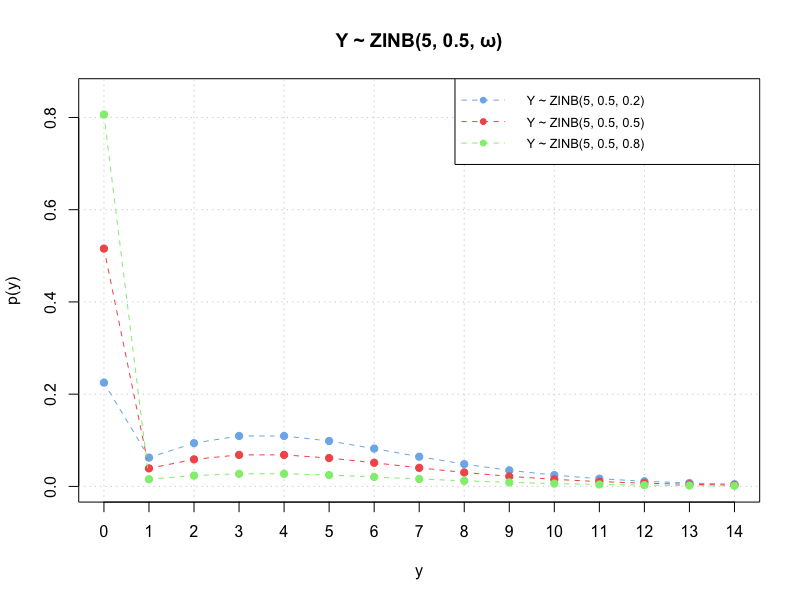

In [21]:
par(bg = "white", mfrow = c(1, 1)) 
fixed_r <- 5
fixed_p <- 0.5
omegas  <- c(0.2, 0.5, 0.8)

y_values  <- 0:14
my_colors <- c("#7cb5ec", "#f45b5b", "#90ed7d")
plot(0, 0, type = "n",
     xlim = c(0, 14),
     ylim = c(0, 0.85),
     xlab = "y",
     ylab = "p(y)",
     main = "Y ~ ZINB(5, 0.5, \u03c9)",
     xaxt = "n")

grid(nx = NULL, ny = NULL, col = "lightgray", lty = "dotted")
axis(1, at = y_values)

for(i in 1:3) {
  probs <- dzinegbin(y_values,
                     size  = fixed_r,      
                     prob  = fixed_p,      
                     pstr0 = omegas[i])   
  
  lines(y_values, probs,
        type = "b",
        pch = 19,
        lty = 2,
        col = my_colors[i])
}

legend("topright",
       legend = paste0("Y ~ ZINB(", fixed_r, ", ", fixed_p, ", ", omegas, ")"),
       col = my_colors,
       pch = 19,
       lty = 2,
       bg = "white",
       cex = 0.8)


### Zero - Truncated Poisson Distribution


In [22]:

dztpois

function (x, lambda, log = FALSE) 
.External(C_actuar_do_dpq, "dztpois", x, lambda, log)
<bytecode: 0x7fd0160f22d8>
<environment: namespace:actuar>

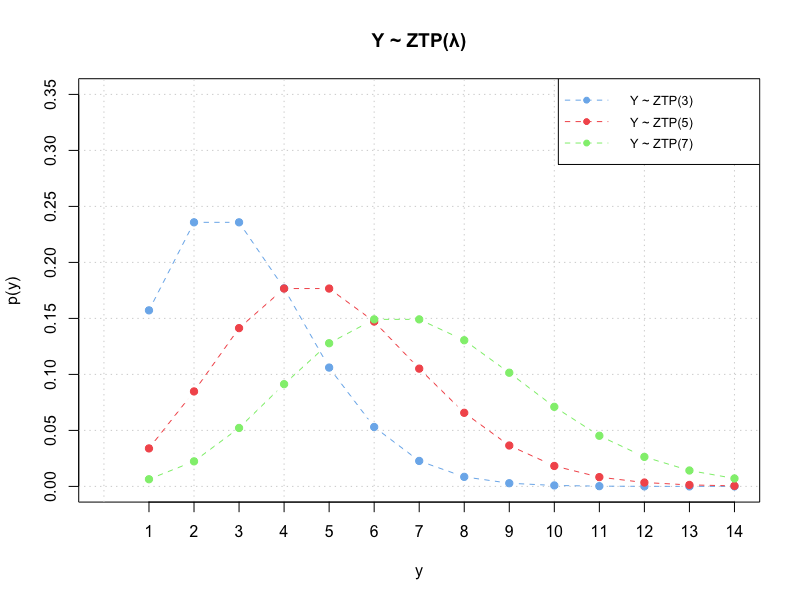

In [23]:
par(bg = "white", mfrow = c(1, 1))

y_values  <- 1:14    
lambdas   <- c(3, 5, 7)
my_colors <- c("#7cb5ec", "#f45b5b", "#90ed7d")

plot(0, 0, type = "n",
     xlim = c(0, 14),
     ylim = c(0, 0.35),
     xlab = "y",
     ylab = "p(y)",
     main = "Y ~ ZTP(\u03bb)",
     xaxt = "n")

grid(nx = NULL, ny = NULL, col = "lightgray", lty = "dotted")
axis(1, at = y_values)

for(i in 1:3) {
  probs <- dztpois(y_values, lambdas[i])
  
  lines(y_values, probs,
        type = "b",
        pch = 19,
        lty = 2,
        col = my_colors[i])
}
legend("topright",
       legend = paste0("Y ~ ZTP(", lambdas,")"),
       col = my_colors,
       pch = 19,
       lty = 2,
       bg = "white",
       cex = 0.8)




### Zero Truncated Negative Binominal

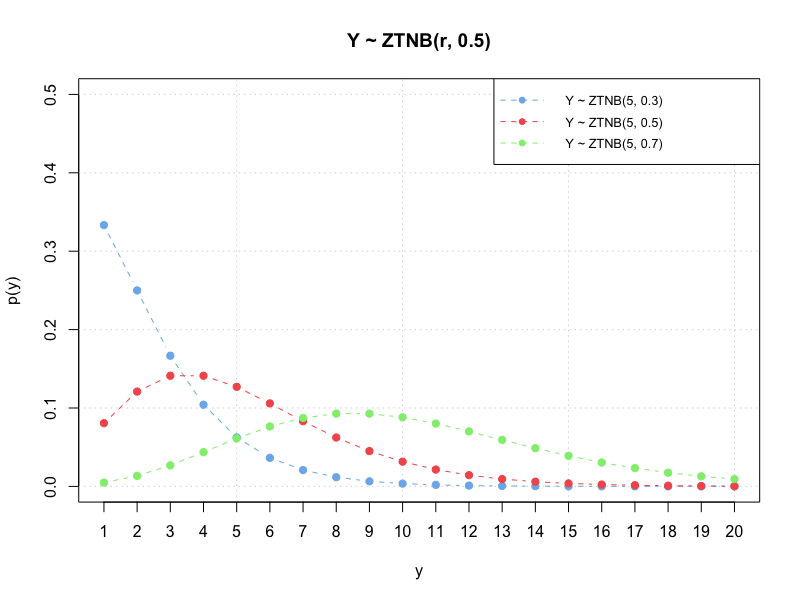

In [30]:
 
 


y_values <- 1:20
my_colors <- c("#7cb5ec", "#f45b5b", "#90ed7d")

par(bg = "white", mfrow = c(1, 1)) 

fixed_p <- 0.5
rs      <- c(2, 5, 10)  # size parameters

plot(0, 0, type = "n",
     xlim = c(1, 20),
     ylim = c(0, 0.50),
     xlab = "y",
     ylab = "p(y)",
     main = "Y ~ ZTNB(r, 0.5)",
     xaxt = "n")

grid(nx = NULL, ny = NULL, col = "lightgray", lty = "dotted")
axis(1, at = y_values)

for(i in 1:3) {
  probs <- dztnbinom(y_values,
                     size = rs[i],
                     prob = fixed_p)  
  lines(y_values, probs,
        type = "b",
        pch = 19,
        lty = 2,
        col = my_colors[i])
}

legend("topright",
       legend = paste0("Y ~ ZTNB(", fixed_r, ", ", ps,")"),
       col = my_colors,
       pch = 19,
       lty = 2,
       bg = "white",
       cex = 0.8)


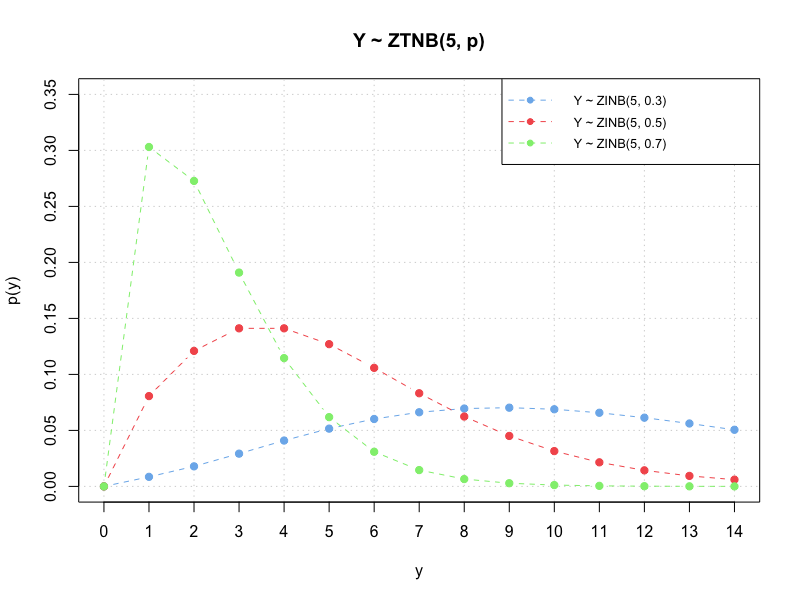

In [25]:
par(bg = "white", mfrow = c(1, 1)) 
fixed_r     <- 5
ps          <- c(0.3, 0.5, 0.7)
y_values    <- 0:14
my_colors   <- c("#7cb5ec", "#f45b5b", "#90ed7d")

plot(0, 0, type = "n",
     xlim = c(0, 14),
     ylim = c(0, 0.35),
     xlab = "y",
     ylab = "p(y)",
     main = "Y ~ ZTNB(5, p)",
     xaxt = "n")

grid(nx = NULL, ny = NULL, col = "lightgray", lty = "dotted")
axis(1, at = y_values)

for(i in 1:3) {
  probs <- dztnbinom(y_values,
                     size  = fixed_r,     
                     prob  = ps[i],     
                     )
  
  lines(y_values, probs,
        type = "b",
        pch = 19,
        lty = 2,
        col = my_colors[i])
}

legend("topright",
       legend = paste0("Y ~ ZINB(", fixed_r, ", ", ps,")"),
       col = my_colors,
       pch = 19,
       lty = 2,
       bg = "white",
       cex = 0.8)
